In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator, MultipleLocator

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

In [2]:
# proj_path = "/home/4cv/project/gc_openPMD-viewer/"
proj_path = "/data/gc_openPMD-viewer/"

df_path = proj_path + "results/final/middle_13000_1234522232425.csv"
df = pd.read_csv(df_path, header=[0])

## Data Pre-processing

In [3]:
def process_df(df):
    
    print("Before Sampling, each group size:")
    print(df.groupby(['target_percentage', 'select_set']).size() / 7)
    
    number_of_each_group = 10
    target_percentage = "0.01%"
    
    # Filter DataFrame by target_percentage
    df_filtered = df[df['target_percentage'] == target_percentage]
    
    # Group by select_set and get unique envelope values for each group
    unique_envelopes = df_filtered.groupby('select_set')['envelope'].unique().reset_index()
    
    # Rename columns for clarity
    unique_envelopes.columns = ['select_set', 'unique_envelopes']
    
    # print the number of unique envelopes for each group
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['unique_envelopes'][i])} unique envelopes.")
    
    # Function to sample envelopes
    # def sample_envelopes(envelopes, n):
    #     return list(envelopes.sample(n=min(n, len(envelopes))))
    
    # Apply the sampling to each group
    # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: list(pd.Series(x).sample(number_of_each_group)))
    # # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: sample_envelopes(pd.Series(x), number_of_each_group))
    #
    # # Clean up the DataFrame by dropping the original unique envelopes column
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['sampled_envelopes'][i])} sampled envelopes.")
    
    unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes']
    
    # Explode the sampled_envelopes into separate rows
    exploded_unique_envelopes = unique_envelopes.explode('sampled_envelopes')
    
    # Merge the exploded_unique_envelopes back to df_filtered to keep only relevant rows
    filtered_df = df_filtered.merge(exploded_unique_envelopes[['select_set', 'sampled_envelopes']],
                                    left_on=['select_set', 'envelope'],
                                    right_on=['select_set', 'sampled_envelopes'])
    
    # Drop the 'sampled_envelopes' column as it's now redundant
    filtered_df = filtered_df.drop(columns='sampled_envelopes')
    
    print("")
    print(filtered_df.groupby(['target_percentage', 'select_set']).size() / 7)
    
    filtered_df = filtered_df[['select_set', 'test_type', 'query_index_time_elapsed', 'remove_duplication_time_elapsed',
                               'sort_block_metadata_time_elapsed', 'find_optimal_read_solution_time_elapsed',
                               'get_target_data_time_elapsed', 'get_support_data_time_elapsed',
                               'data_calculation_time_elapsed', 'data_apply_select_time_elapsed', 'apply_particle_level_select_array_time_elapsed', 'total_time_elapsed', 'query_result_size', 'chunk_range_size']]
    
    filtered_df['indexing'] = filtered_df['query_index_time_elapsed'] + df['remove_duplication_time_elapsed'] + df['sort_block_metadata_time_elapsed'] + df['find_optimal_read_solution_time_elapsed']
    filtered_df['indexing_without_grouping'] = filtered_df['query_index_time_elapsed'] + np.where(df['remove_duplication_time_elapsed'].notna(), df['remove_duplication_time_elapsed'], 0)
    filtered_df['IO_time'] = filtered_df['get_target_data_time_elapsed'] + df['get_support_data_time_elapsed']
    filtered_df['calculation'] = filtered_df['data_calculation_time_elapsed'] + df['data_apply_select_time_elapsed'] + df['apply_particle_level_select_array_time_elapsed']
    
    filtered_df = filtered_df[['select_set', 'test_type', 'indexing', 'indexing_without_grouping', 'IO_time', 'calculation', 'total_time_elapsed', 'query_result_size', 'chunk_range_size']]
    
    # Group by select_set and test_type, then compute the average value
    averaged_df = filtered_df.groupby(['select_set', 'test_type']).mean().reset_index()
    
    
    # only keep the select_set with specific values: ('ux',),  ('ux','uy'),  ('ux','uy','uz'),  ('ux','uy','uz','x'), ('ux','uy','uz','x','y'), ('ux','uy','uz','x','y','z')
    averaged_df = averaged_df[averaged_df['select_set'].isin(["('ux',)", "('ux','uy')", "('ux','uy','uz')", "('ux','uy','uz','x')", "('ux','uy','uz','x','y')", "('ux','uy','uz','x','y','z')"])]
    
    # a new column to indicate the length of select_set
    averaged_df['select_set_length'] = averaged_df['select_set'].apply(lambda x: len(eval(x)))
    
    # sort by select_set_length
    averaged_df = averaged_df.sort_values('select_set_length')

    return averaged_df


In [4]:
# Define a formatter function for y-axis labels
def exp_formatter(y, pos):
    if y == 0:
        return r"0"
    return r"$\mathregular{{10}}^{{\mathregular{{{}}}}}$".format(int(y))

In [5]:
global_tick_fontsize = 20
global_label_fontsize = 20
global_annotation_fontsize = 18
global_legend_fontsize = 18

### Overall query time comparison 

In [6]:
averaged_df = process_df(df)

Before Sampling, each group size:
target_percentage  select_set                  
0.01%              ('ux','uy')                     19.285714
                   ('ux','uy','uz')                29.571429
                   ('ux','uy','uz','x')            19.285714
                   ('ux','uy','uz','x','y')        19.285714
                   ('ux','uy','uz','x','y','z')    36.000000
                   ('ux','uy','x','y')             19.285714
                   ('ux',)                         19.285714
                   ('x','y')                       19.285714
                   ('x','y','z')                   25.714286
                   ('x',)                          19.285714
dtype: float64

target_percentage  select_set                  
0.01%              ('ux','uy')                     19.285714
                   ('ux','uy','uz')                29.571429
                   ('ux','uy','uz','x')            19.285714
                   ('ux','uy','uz','x','y')        19.285714


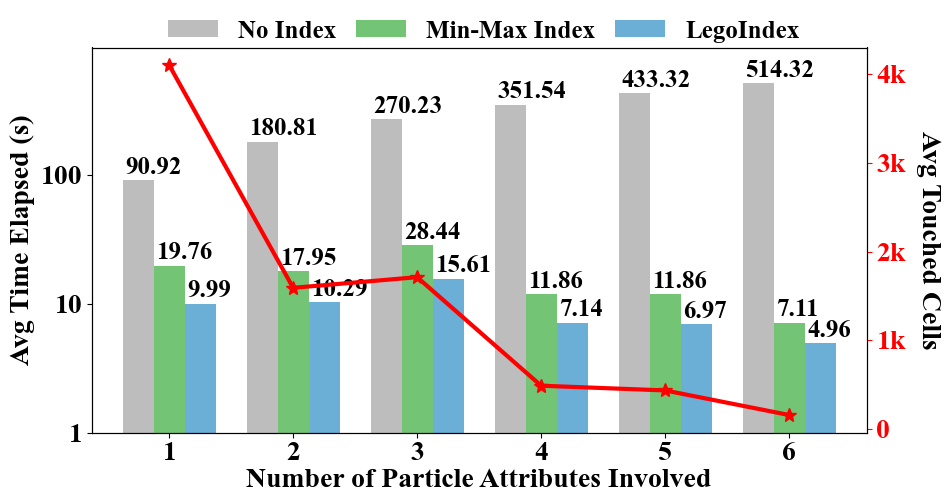

In [7]:


# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]

fig, ax = plt.subplots()
# set figure size
fig.set_size_inches(10, 5)

# the value difference between test_type 1 and 25 is too large, so we use log scale
plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))


# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0.07, 1.13), columnspacing=0.8)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for p in ax.patches:
    ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() + 0.02, p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 2.99)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, fontweight='bold', labelpad=2)
# y label
plt.ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize, fontweight='bold')

current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='red', marker='*', markersize=10, linewidth=3)
# plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='chunk_range_size').plot(kind='line', ax=ax2, color='red', marker='o', markersize=8, linewidth=2)
# plt.ylim(0, 880)

# y label
plt.ylabel("Avg Touched Cells", fontsize=global_label_fontsize, rotation=270, labelpad=25, fontweight='bold')
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(1000))
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize, colors='red')  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')


plt.savefig(proj_path + "plot/final/overall_query_time_comparison_middle.pdf", bbox_inches='tight', pad_inches=0.1)

plt.show()

print()

### CPU Calculation Comparison

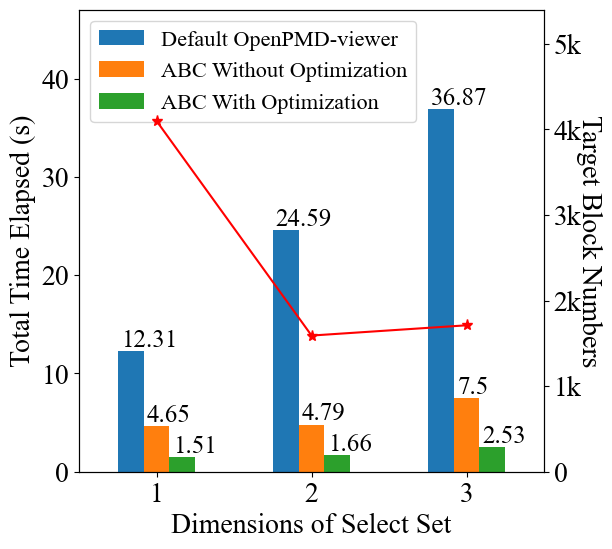

In [8]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([1, 5, 25])]

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['calculation'] = plot_df['calculation'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 6)




# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='calculation').plot(kind='bar', ax=ax)

ax.legend(title='', loc='upper left', labels=['Default OpenPMD-viewer', 'ABC Without Optimization', 'ABC With Optimization'], fontsize=global_legend_fontsize - 2)

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() + 0.02, p.get_height() + 0.05), fontsize=global_annotation_fontsize)
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() + 0.02, p.get_height() + 0.45), fontsize=global_annotation_fontsize)

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 47)
# x label
plt.xlabel("Dimensions of Select Set", fontsize=global_label_fontsize)
# y label
plt.ylabel("Total Time Elapsed (s)", fontsize=global_label_fontsize)

current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(10))
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)  # Adjust label size as needed
# plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[plot_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='red', marker='*', markersize=8)
# averaged_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='chunk_range_size').plot(kind='line', ax=ax2, color='blue', marker='o')



plt.ylim(0, 5400)

# y label
plt.ylabel("Target Block Numbers", fontsize=global_label_fontsize, rotation=270, labelpad=15)
current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_locator(MultipleLocator())
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))


# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()

plt.savefig(proj_path + "plot/final/cpu_cost_comparison_middle.pdf", bbox_inches='tight', pad_inches=0.1)

plt.show()

print()


### IO Grouping Comparison

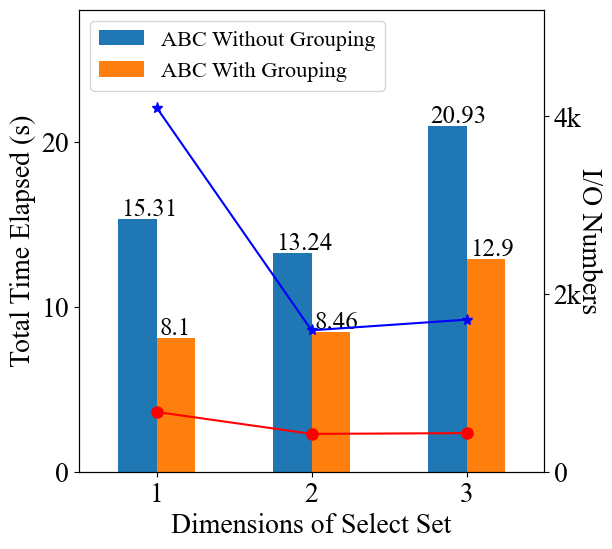

In [9]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 6)


# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax)

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() + 0.02, p.get_height() + 0.2), fontsize=global_annotation_fontsize)
    
ax.legend(title='', loc='upper left', labels=['ABC Without Grouping', 'ABC With Grouping'], fontsize=global_legend_fontsize - 2)

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 28)
# x label
plt.xlabel("Dimensions of Select Set", fontsize=global_label_fontsize)
# y label
plt.ylabel("Total Time Elapsed (s)", fontsize=global_label_fontsize)

# current_values = plt.gca().get_yticks()
from matplotlib.ticker import MaxNLocator, MultipleLocator
plt.gca().yaxis.set_major_locator(MultipleLocator(10))
# plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)  # Adjust label size as needed
    
# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='blue', marker='*', markersize=8)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='chunk_range_size').plot(kind='line', ax=ax2, color='red', marker='o', markersize=8)


plt.ylim(0, 5200)

# y label
plt.ylabel("I/O Numbers", fontsize=global_label_fontsize, rotation=270, labelpad=15)
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()

plt.savefig(proj_path + "plot/final/io_grouping_comparison_middle.pdf", bbox_inches='tight', pad_inches=0.1)

plt.show()

print()

# IO cost proportion comparison

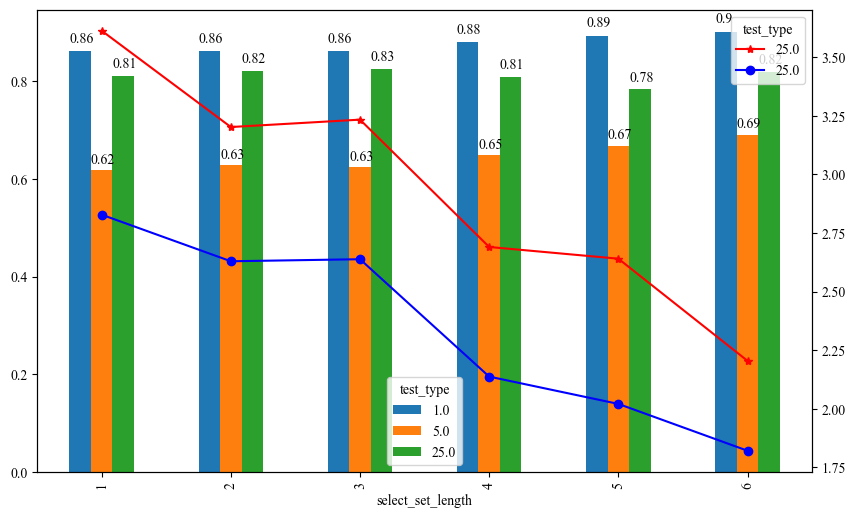

In [10]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([1, 5, 25])]


plot_df['IO_Percent'] = plot_df['IO_time'] / plot_df['total_time_elapsed']

# the value difference between test_type 1 and 25 is too large, so we use log scale
# averaged_df['IO_time'] = averaged_df['IO_time'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(10, 6)


# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_Percent').plot(kind='bar', ax=ax)

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[plot_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='red', marker='*')
plot_df[plot_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='chunk_range_size').plot(kind='line', ax=ax2, color='blue', marker='o')



# set the x-axis label to be hrizontal
plt.xticks(rotation=0)
plt.show()

print()

In [11]:
middle_block_small_path = proj_path + "results/final/middle_16.csv"
middle_block_large_path = proj_path + "results/final/middle_13000_1234522232425.csv"
middle_block_super_path = proj_path + "results/final/middle_1M.csv"

middle_block_small_df = pd.read_csv(middle_block_small_path, header=[0])
middle_block_large_df = pd.read_csv(middle_block_large_path, header=[0])
middle_block_super_df = pd.read_csv(middle_block_super_path, header=[0])

middle_block_small_df = process_df(middle_block_small_df)
middle_block_large_df = process_df(middle_block_large_df)
middle_block_super_df = process_df(middle_block_super_df)

# merge the two dataframes, and one column to indicate the size of block
middle_block_small_df['block_size'] = 'Small'
middle_block_large_df['block_size'] = 'Middle'
middle_block_super_df['block_size'] = 'Large'

Before Sampling, each group size:
target_percentage  select_set      
0.01%              ('ux','uy')         6.428571
                   ('ux','uy','uz')    6.428571
                   ('ux',)             4.285714
dtype: float64

target_percentage  select_set      
0.01%              ('ux','uy')         6.428571
                   ('ux','uy','uz')    6.428571
                   ('ux',)             4.285714
dtype: float64
Before Sampling, each group size:
target_percentage  select_set                  
0.01%              ('ux','uy')                     19.285714
                   ('ux','uy','uz')                29.571429
                   ('ux','uy','uz','x')            19.285714
                   ('ux','uy','uz','x','y')        19.285714
                   ('ux','uy','uz','x','y','z')    36.000000
                   ('ux','uy','x','y')             19.285714
                   ('ux',)                         19.285714
                   ('x','y')                       19.285714
     

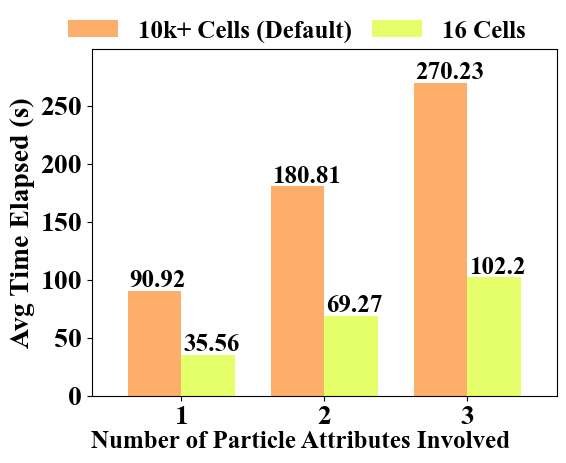

In [12]:

plot_df = pd.concat([middle_block_small_df, middle_block_large_df])

plot_df = plot_df[plot_df['select_set_length'] <= 3]

plot_df = plot_df[plot_df['test_type'] == 1]

# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4.5)

color = ['#fdae6b', '#e5ff6b']

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='block_size', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=color)

legend = ax.legend(title='', loc='upper left', labels=['10k+ Cells (Default)', '16 Cells'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-0.1, 1.15), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() + 0.015, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 299)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize-2, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_blocks.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


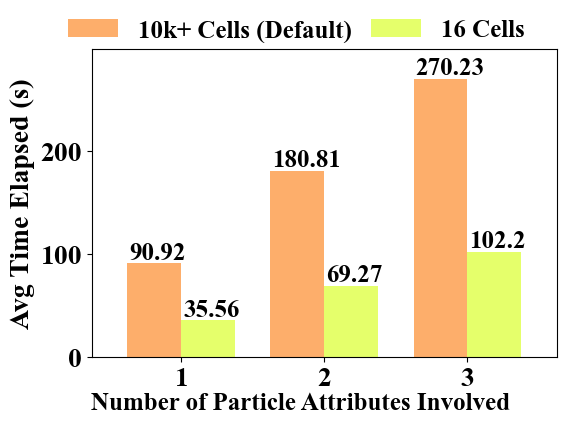

In [13]:

plot_df = pd.concat([middle_block_small_df, middle_block_large_df])

plot_df = plot_df[plot_df['select_set_length'] <= 3]

plot_df = plot_df[plot_df['test_type'] == 1]

# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4)

color = ['#fdae6b', '#e5ff6b']

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='block_size', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=color)

legend = ax.legend(title='', loc='upper left', labels=['10k+ Cells (Default)', '16 Cells'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-0.1, 1.17), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() + 0.015, p.get_height() + 4), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 299)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize-2, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_blocks_v2.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


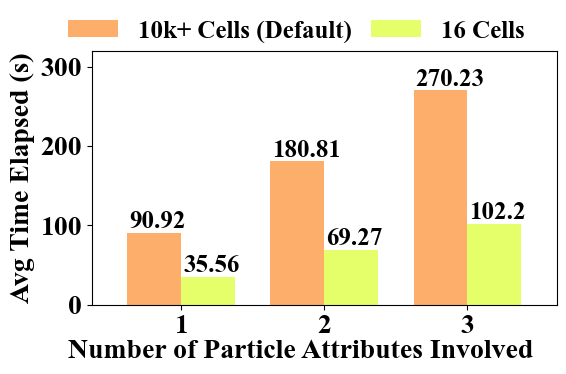

In [44]:

plot_df = pd.concat([middle_block_small_df, middle_block_large_df])

plot_df = plot_df[plot_df['select_set_length'] <= 3]

plot_df = plot_df[plot_df['test_type'] == 1]

# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 3.3)

color = ['#fdae6b', '#e5ff6b']

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='block_size', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=color)

legend = ax.legend(title='', loc='upper left', labels=['10k+ Cells (Default)', '16 Cells'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-0.1, 1.21), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() + 0.015, p.get_height() + 6), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 320)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_blocks_v3.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()


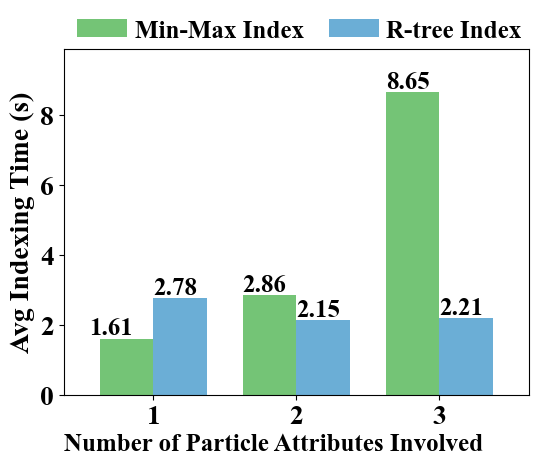

In [14]:

# plot_df = pd.concat([middle_block_small_df, middle_block_large_df, middle_block_super_df])
plot_df = middle_block_super_df

plot_df = plot_df[plot_df['test_type'].isin([24, 25])]
# print(plot_df)
# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4.5)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='indexing_without_grouping').plot(kind='bar', ax=ax, width=0.75, color=['#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['Min-Max Index', 'R-tree Index'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-0.02, 1.15), columnspacing=1, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    if i == 0:
        ax.annotate(str(round(p.get_height(), 2)), (p.get_x()-0.07, p.get_height() + 0.12), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 2)), (p.get_x(), p.get_height() + 0.12), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 9.9)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 2, labelpad=3, fontweight='bold')
# y label
plt.ylabel("Avg Indexing Time (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_index_large.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


In [15]:
fastbit_df = pd.read_csv(proj_path + 'results/final/middle_fbindex_1.csv', header=[0])
fastbit_df['select_set_length'] = fastbit_df['select_set'].apply(lambda x: len(eval(x)))
fastbit_df['test_type'] = 19
fastbit_df['indexing_without_grouping'] = fastbit_df['fbindex_ux'] + fastbit_df['fbindex_uy'] + fastbit_df['fbindex_uz'] + fastbit_df['fbindex_interaction']
fastbit_df = fastbit_df[['select_set_length', 'test_type', 'indexing_without_grouping']]
fastbit_df

,select_set_length,test_type,indexing_without_grouping
0,1,19,2.154235
1,1,19,1.963624
2,1,19,6.815873
3,1,19,2.184768
4,1,19,2.215971
5,1,19,2.087796
6,1,19,1.871341
7,1,19,5.157140
8,1,19,2.252935
9,1,19,2.213543


In [16]:
fastbit_df_avg = fastbit_df.groupby(['select_set_length', 'test_type']).mean().reset_index()
fastbit_df_avg

,select_set_length,test_type,indexing_without_grouping
0,1,19,3.149882
1,2,19,5.927080
2,3,19,8.737649


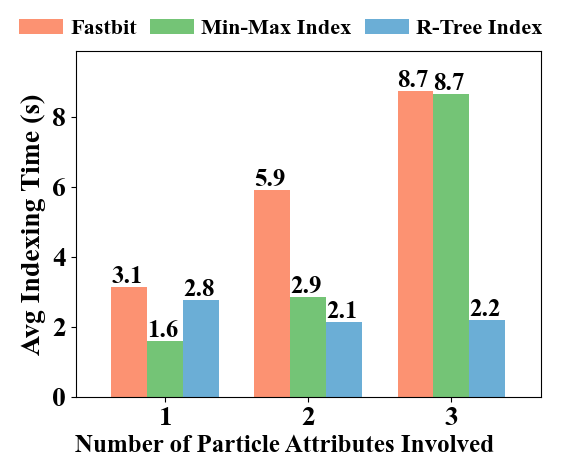

In [17]:

# plot_df = pd.concat([middle_block_small_df, middle_block_large_df, middle_block_super_df])
plot_df = middle_block_super_df
plot_df = plot_df[plot_df['test_type'].isin([24, 25])]
plot_df = pd.concat([plot_df, fastbit_df_avg])
plot_df = plot_df[plot_df['select_set_length'] <= 3]
plot_df = plot_df[plot_df['test_type'].isin([19, 24, 25])]
plot_df

# print(plot_df)
# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4.5)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='indexing_without_grouping').plot(kind='bar', ax=ax, width=0.75, color=['#fc9272', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['Fastbit', 'Min-Max Index', 'R-Tree Index'], fontsize=global_legend_fontsize - 2, ncol=3, frameon=False, bbox_to_anchor=(-0.165, 1.15), columnspacing=0.6, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.12), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 9.9)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 2, labelpad=3, fontweight='bold')
# y label
plt.ylabel("Avg Indexing Time (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_index_large.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


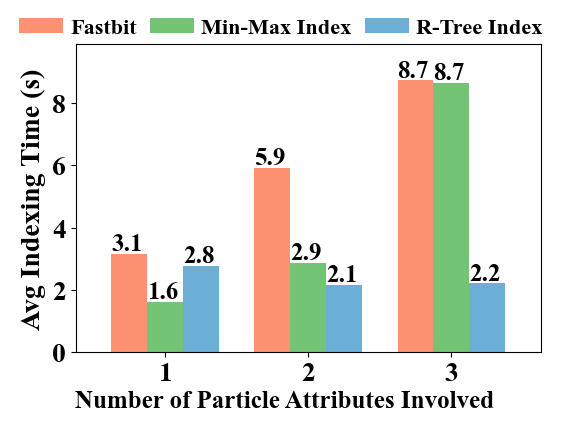

In [18]:

# plot_df = pd.concat([middle_block_small_df, middle_block_large_df, middle_block_super_df])
plot_df = middle_block_super_df
plot_df = plot_df[plot_df['test_type'].isin([24, 25])]
plot_df = pd.concat([plot_df, fastbit_df_avg])
plot_df = plot_df[plot_df['select_set_length'] <= 3]
plot_df = plot_df[plot_df['test_type'].isin([19, 24, 25])]
plot_df

# print(plot_df)
# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='indexing_without_grouping').plot(kind='bar', ax=ax, width=0.75, color=['#fc9272', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['Fastbit', 'Min-Max Index', 'R-Tree Index'], fontsize=global_legend_fontsize - 2, ncol=3, frameon=False, bbox_to_anchor=(-0.165, 1.15), columnspacing=0.6, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.12), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 9.9)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 2, labelpad=3, fontweight='bold')
# y label
plt.ylabel("Avg Indexing Time (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_index_large_v2.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


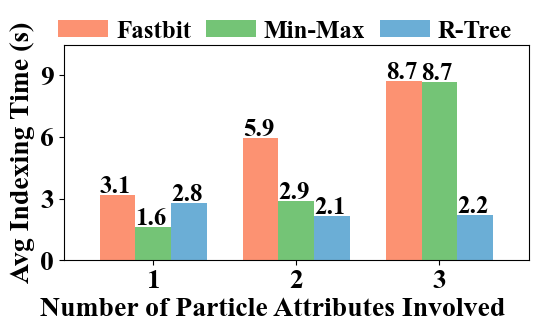

In [34]:

# plot_df = pd.concat([middle_block_small_df, middle_block_large_df, middle_block_super_df])
plot_df = middle_block_super_df
plot_df = plot_df[plot_df['test_type'].isin([24, 25])]
plot_df = pd.concat([plot_df, fastbit_df_avg])
plot_df = plot_df[plot_df['select_set_length'] <= 3]
plot_df = plot_df[plot_df['test_type'].isin([19, 24, 25])]
plot_df

# print(plot_df)
# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 2.8)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='indexing_without_grouping').plot(kind='bar', ax=ax, width=0.75, color=['#fc9272', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['Fastbit', 'Min-Max', 'R-Tree'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.06, 1.22), columnspacing=0.6, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.12), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 10.5)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=3, fontweight='bold')
# y label
plt.ylabel("Avg Indexing Time (s)", fontsize=global_label_fontsize, fontweight='bold')

label = plt.gca().xaxis.label
x, y = label.get_position()
plt.gca().xaxis.label.set_position((x - 0.05, y))

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
ax.yaxis.set_major_locator(MultipleLocator(3))

# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_index_large_v3.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


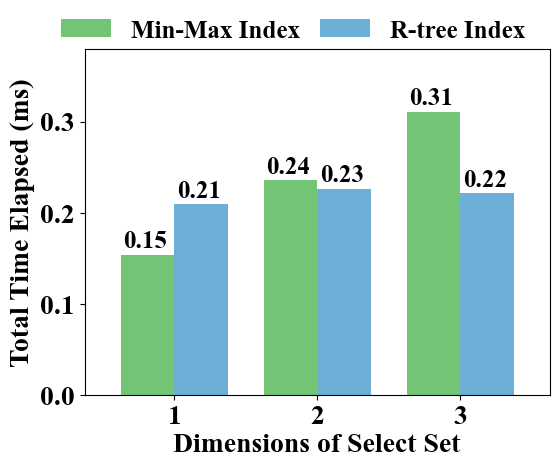

In [20]:

# plot_df = pd.concat([middle_block_small_df, middle_block_large_df, middle_block_super_df])
plot_df = middle_block_small_df
plot_df = plot_df[plot_df['test_type'].isin([24, 25])]

plot_df['indexing_without_grouping'] = plot_df['indexing_without_grouping'] * 1000

# print(plot_df)
# plot total time elapsed in bar
fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(6, 4.5)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='indexing_without_grouping').plot(kind='bar', ax=ax, width=0.75, color=['#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['Min-Max Index', 'R-tree Index'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(-0.1, 1.15), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() + 0.02, p.get_height() + 0.008), fontsize=global_annotation_fontsize, fontweight='bold')
    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 2)), (p.get_x()-0.03, p.get_height() + 0.004), fontsize=global_annotation_fontsize, fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 2)), (p.get_x(), p.get_height() + 0.004), fontsize=global_annotation_fontsize, fontweight='bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 0.38)
# x label
plt.xlabel("Dimensions of Select Set", fontsize=global_label_fontsize, labelpad=3, fontweight='bold')
# y label
plt.ylabel("Total Time Elapsed (ms)", fontsize=global_label_fontsize, fontweight='bold')

current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# plt.gca().set_yticklabels([str(int(pow(10, y))) for y in plt.gca().get_yticks()])

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Remove the legend
# plt.gca().get_legend().remove()

plt.yticks(fontweight='bold')

plt.savefig(proj_path + "plot/final/middle_diff_index_small.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()
print()


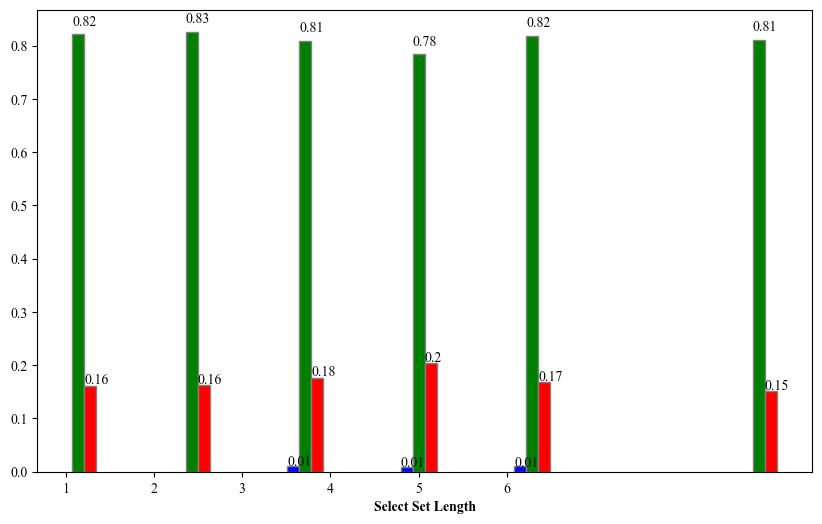

In [21]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([25])]

plot_df['indexing_Percent'] = plot_df['indexing'] / plot_df['total_time_elapsed']
plot_df['IO_Percent'] = plot_df['IO_time'] / plot_df['total_time_elapsed']
plot_df['calculation_Percent'] = plot_df['calculation'] / plot_df['total_time_elapsed']



fig, ax = plt.subplots()

# set figure size
fig.set_size_inches(10, 6)


# plot grouped bar chart, x is select_set_length, plot the percentage of each part in total time_elapsed
# Define bar width
bar_width = 0.95

# Set positions of the bars on the x-axis
r1 = plot_df.index
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Create bars
ax.bar(r1, plot_df['indexing_Percent'], color='b', width=bar_width, edgecolor='grey', label='Indexing')
ax.bar(r2, plot_df['IO_Percent'], color='g', width=bar_width, edgecolor='grey', label='I/O')
ax.bar(r3, plot_df['calculation_Percent'], color='r', width=bar_width, edgecolor='grey', label='Calculation')


# Add xticks on the middle of the group bars
ax.set_xlabel('Select Set Length', fontweight='bold')
ax.set_xticks([r*7 + bar_width + 7 for r in range(len(plot_df))])
ax.set_xticklabels(plot_df['select_set_length'])

# mark the number on the top of each bar before log
for p in ax.patches:
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
                

# set the x-axis label to be hrizontal
plt.xticks(rotation=0)
plt.show()

print()